# Binarna klasifikacija pomoću višeslojnog perceptrona

In [1]:
# Import potrebnih modula /  klasa i funkcija
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
import matplotlib.pyplot as plt

## Učitavanje skupa podataka

U ovom zadatku koristimo **Breast Cancer dataset** iz biblioteke scikit-learn.  
Ovaj skup podataka se često koristi za zadatke **binarne klasifikacije**.

📄 Dokumentaciji možete pristupiti [ovde](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)

In [2]:
# Učitati Breast Cancer dataset i izdvojiti ulazne podatke (X) i ciljne vrednosti (y)
cancer_data = load_breast_cancer()

X = cancer_data.data
y = cancer_data.target

## Pregled skupa podataka

In [3]:
# Prikazati kratak opis dataset-a
type(cancer_data)
print("Ključevi u dataset-u:", cancer_data.keys())
print("\n--- KRATAK OPIS DATASET-A ---")
print(cancer_data.DESCR[:500] + "...")

Ključevi u dataset-u: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

--- KRATAK OPIS DATASET-A ---
.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (...


## Podela na trening i test **skupove**

In [4]:
# Podeliti podatke na trening (80%) i test (20%) skup
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Skaliranje / standardizacija podataka

In [5]:
# Standardizovati varijable
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Kreiranje modela

📄 Dokumentacija za **MLPClassifier** dostupna je [ovde](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)

In [6]:
# Kreirati MLPClassifier model sa skrivenim slojevima (64, 32), maksimalnim brojem iteracija 1000 i postaviti random state
mlp1 = MLPClassifier(
    hidden_layer_sizes=(64,32),
    max_iter=1000,
    random_state=42,
)

In [7]:
# Prikazati osnovne informacije o arhitekturi mreže
print("Arhitektura mreze:")
print("Broj ulaznih neurona:", X_train.shape[1])
print("Skriveni slojevi:", mlp1.hidden_layer_sizes)

Arhitektura mreze:
Broj ulaznih neurona: 30
Skriveni slojevi: (64, 32)


## Trening modela

In [8]:
# Istrenirati model
mlp1.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

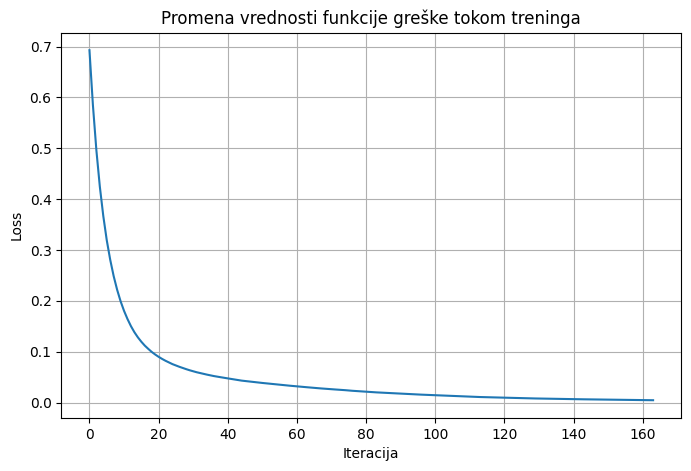

In [9]:
# Prikazati promenu vrednosti funkcije greške (loss) tokom treninga
plt.figure(figsize=(8,5))
plt.plot(mlp1.loss_curve_)
plt.xlabel("Iteracija")
plt.ylabel("Loss")
plt.title("Promena vrednosti funkcije greške tokom treninga")
plt.grid()
plt.show()

In [10]:
# Prikazati osnovne informacije o modelu nakon treninga (broj izlaza, dimenzije težina i bias vektora, broj iteracija i finalni loss)
print("\nBroj izlaznih neurona:", mlp1.n_outputs_)

for i, coef in enumerate(mlp1.coefs_):
    print(f"Matrica tezina {i+1}: {coef.shape}")

for i, bias in enumerate(mlp1.intercepts_):
    print(f"Bias vektor {i+1}: {bias.shape}")

print("\nBroj iteracija:", mlp1.n_iter_)
print("Finalni loss:", mlp1.loss_)


Broj izlaznih neurona: 1
Matrica tezina 1: (30, 64)
Matrica tezina 2: (64, 32)
Matrica tezina 3: (32, 1)
Bias vektor 1: (64,)
Bias vektor 2: (32,)
Bias vektor 3: (1,)

Broj iteracija: 164
Finalni loss: 0.004520930761220754


## Kreiranje predikcija

In [11]:
# Izvršiti predikciju
y_pred = mlp1.predict(X_test)
y_proba = mlp1.predict_proba(X_test)

In [12]:
# Prikazati nekoliko primera predikcija
print("Primeri predikcija:")
for i in range(5):
    print(f"Uzorak {i+1}: stvarna klasa = {y_test[i]}, predikcija = {y_pred[i]}, verovatnoce = {y_proba[i]}")

Primeri predikcija:
Uzorak 1: stvarna klasa = 0, predikcija = 0, verovatnoce = [9.99999999e-01 7.86958591e-10]
Uzorak 2: stvarna klasa = 1, predikcija = 1, verovatnoce = [1.39200700e-08 9.99999986e-01]
Uzorak 3: stvarna klasa = 0, predikcija = 0, verovatnoce = [9.99963459e-01 3.65408580e-05]
Uzorak 4: stvarna klasa = 1, predikcija = 0, verovatnoce = [0.64660946 0.35339054]
Uzorak 5: stvarna klasa = 0, predikcija = 0, verovatnoce = [1.00000000e+00 1.48209694e-11]


## Evaluacija modela

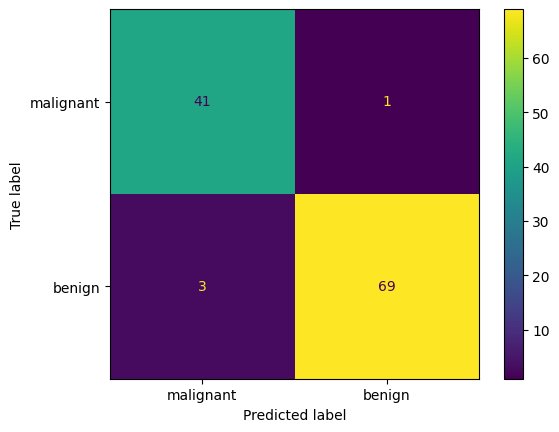

In [13]:
# Kreirati i prikazati matricu konfuzije
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['malignant','benign'])
disp.plot()

In [14]:
# Izračunati tačnost modela i prikazati classification report
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 96.49%
Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



## Eksperimentisanje sa različitim hiperparametrima modela

In [15]:
# Kreirati drugi MLPClassifier model sa istom arhitekturom, uz promenu aktivacione funkcije ('tanh'), početne stope učenja (0.0001) i optimizacionog algoritma ('sgd')
mlp2 = MLPClassifier(
    hidden_layer_sizes=(64,32),
    max_iter=1000,
    random_state=42,
    activation='tanh',
    learning_rate_init=0.0001,
    solver='sgd'
)

In [16]:
# Istrenirati model
mlp2.fit(X_train, y_train)

MLPClassifier(activation='tanh', hidden_layer_sizes=(64, 32),
              learning_rate_init=0.0001, max_iter=1000, random_state=42,
              solver='sgd')

In [17]:
# Izvršiti predikciju
y_pred2 = mlp2.predict(X_test)

In [18]:
# Izračunati tačnost modela i prikazati classification report
accuracy = accuracy_score(y_test, y_pred2)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:\n")
print(classification_report(y_test, y_pred2))

Accuracy: 95.61%
Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        42
           1       0.97      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [19]:
# Kreirati treći MLPClassifier model i postaviti jedan skriveni sloj sa 128 neurona
mlp3 = MLPClassifier(
    hidden_layer_sizes=(128,),
    max_iter=1000,
    random_state=42,
    activation='tanh',
    learning_rate_init=0.0001,
    solver='sgd'
)

In [20]:
# Istrenirati model
mlp3.fit(X_train, y_train)

MLPClassifier(activation='tanh', hidden_layer_sizes=(128,),
              learning_rate_init=0.0001, max_iter=1000, random_state=42,
              solver='sgd')

In [21]:
# Izvršiti predikciju
y_pred3 = mlp3.predict(X_test)

In [22]:
# Izračunati tačnost modela i prikazati classification report
accuracy = accuracy_score(y_test, y_pred3)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:\n")
print(classification_report(y_test, y_pred3))

Accuracy: 96.49%
Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        42
           1       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

